# Decision: ESP Sampling Method Strategy

**Status:** Under investigation  
**Decision to make:** How to map ESP values from the APBS `.dx` voxel grid onto SES mesh vertices.

## Problem
The `.dx` file is a regular voxel grid of ESP values that does not align with SES mesh vertices.
Three candidate methods are evaluated here:

| Method | Description | Risk |
|--------|-------------|------|
| **Nearest Neighbour** | Snap each vertex to the closest voxel centre | Discontinuities; grid-resolution artifacts |
| **Trilinear Interpolation** | Weighted average of the 8 surrounding voxels | Smoother; may smear sharp features |
| **Laplacian Smoothing** | Trilinear at all vertices, then iteratively average each vertex with its mesh neighbours | Very smooth; number of iterations controls smoothing strength; subsampling explored separately |

Each method is run on both the **PDB mesh** (no hydrogens) and the **PQR mesh** (with hydrogens).  
A difference heatmap in column 3 of each row shows `|ESP_PQR − ESP_PDB|` projected onto the PDB mesh,
revealing where the choice of structure (H vs no-H) matters most.

---
**Conclusion:** *(fill in after running)*  
**Decision recorded in:** `THESISPROCESSES.md`

In [18]:
# ── Display setup ─────────────────────────────────────────────────────────────
import os
os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")

'/run/user/1000/'

In [19]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import pyvista as pv
from IPython.display import display as ipy_display, Image as ipy_Image
import PIL.Image, io

# Off-screen rendering — displays inline in the notebook.
# To rotate interactively, run the "Interactive terminal" cell at the bottom.
pv.set_jupyter_backend("static")

PROJECT_ROOT = Path("../").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_config
from src.utils.paths import ProteinPaths
from src.surface.esp_mapping import read_dx, offset_points, interpolate_faces_from_verts
from src.surface.mesh import xyzr_from_pqr, run_msms

cfg       = get_config()
data_root = PROJECT_ROOT / "data"
print("data_root:", data_root)

data_root: /home/skyle/external_protein_data


In [ ]:
# ── Protein selection ─────────────────────────────────────────────────────────
PROTEIN_IDS = [
    "AF-P01082-F1",       # small   ~7 600 vertices
    "AF-Q16613-F1",       # medium  ~30 500 vertices
    "AF-B1WC58-F1",       # large   ~215 000 vertices
]

# Normal offset in Å — held fixed pending normal_offset_strategy.ipynb decision
NORMAL_OFFSET = cfg["esp_mapping"]["normal_offset"]

# Laplacian smoothing: number of averaging iterations
# More iterations = smoother field; 0 = trilinear with no smoothing
N_SMOOTH_ITER = 10

print(f"Normal offset : {NORMAL_OFFSET} Å")
print(f"Smooth iters  : {N_SMOOTH_ITER}")

Normal offset : 0.5 Å
Smooth iters  : 10


In [21]:
# ── Load or regenerate mesh ───────────────────────────────────────────────────
# Uses saved mesh if it exists; otherwise regenerates via MSMS.
# Returns (verts, normals, faces) as float32/int arrays.

class _FakeLog:
    """Minimal logger stub that prints to stdout."""
    def info(self, msg, *args):    print("  [INFO ]", msg % args if args else msg)
    def warning(self, msg, *args): print("  [WARN ]", msg % args if args else msg)
    def error(self, msg, *args):   print("  [ERROR]", msg % args if args else msg)

plog = _FakeLog()


def xyzr_from_pdb(pdb_file: Path, plog) -> tuple:
    """
    Parse a .pdb file and return MSMS-ready xyzr lines and atom positions.
    Van der Waals radii are looked up from MDAnalysis tables by element.
    Removed from src/surface/mesh.py (PQR-only pipeline) — defined locally.
    """
    import MDAnalysis as mda
    from MDAnalysis.topology.tables import vdwradii as mda_vdwradii

    DEFAULT_RADIUS = 1.5
    u     = mda.Universe(str(pdb_file))
    atoms = u.select_atoms("not (resname HOH WAT)")

    xyzr_lines, positions, n_missing = [], [], 0
    for atom in atoms:
        elem   = atom.element.strip().upper() if atom.element.strip() else atom.name[0].upper()
        radius = mda_vdwradii.get(elem, DEFAULT_RADIUS)
        x, y, z = atom.position
        xyzr_lines.append(f"{x:.3f} {y:.3f} {z:.3f} {radius:.3f}")
        positions.append([x, y, z])
        if elem not in mda_vdwradii:
            n_missing += 1

    if n_missing:
        plog.warning("Used default radius (%.1f Å) for %d atoms with unknown element",
                     DEFAULT_RADIUS, n_missing)
    if not xyzr_lines:
        raise ValueError(f"No valid atoms parsed from PDB file: {pdb_file}")
    plog.info("Parsed %d atoms from PDB file", len(xyzr_lines))
    return xyzr_lines, np.array(positions, dtype=np.float32)


def nearest_neighbor_esp(axes, grid, points):
    """
    Nearest-neighbour lookup of ESP from the DX grid.
    Removed from src/surface/esp_mapping.py — defined locally.
    """
    interp_fn = RegularGridInterpolator(
        axes, grid, method="nearest", bounds_error=False, fill_value=None,
    )
    return interp_fn(points).astype(np.float32)


def load_or_build_mesh(struct_file: Path, saved_npz: Path):
    """Return (verts, normals, faces). Load from npz if available."""
    if saved_npz.exists():
        d = np.load(saved_npz)
        plog.info("Loaded mesh from %s  (%d verts)", saved_npz.name, len(d["verts"]))
        return d["verts"], d["normals"], d["faces"]

    plog.info("Regenerating mesh from %s", struct_file.name)
    if struct_file.suffix == ".pqr":
        xyzr_lines, positions = xyzr_from_pqr(struct_file, plog)
    else:
        xyzr_lines, positions = xyzr_from_pdb(struct_file, plog)

    verts, normals, faces, ses_area = run_msms(xyzr_lines, positions, plog)
    plog.info("Mesh: %d verts, %d faces  SES area=%.1f Å²", len(verts), len(faces), ses_area)
    return verts, normals, faces

---
## Method Implementations

Methods 1 (nearest neighbour) is imported from `src/`. Methods 2 (trilinear) and 3 (Laplacian smoothing) are written inline.

In [22]:
# ── Method 2: Trilinear Interpolation ─────────────────────────────────────────

def trilinear_esp(axes, grid, points):
    """
    Trilinear interpolation of ESP values from the DX grid.
    Weights the 8 surrounding voxels by relative distance — C0-continuous,
    no jumps at voxel boundaries unlike nearest-neighbour.
    """
    interp_fn = RegularGridInterpolator(
        axes, grid, method="linear", bounds_error=False, fill_value=None,
    )
    return interp_fn(points).astype(np.float32)


# ── Method 3: Laplacian Smoothing ─────────────────────────────────────────────

def laplacian_smooth(verts, faces, esp_verts, n_iter):
    """
    Smooth ESP values across the mesh by iteratively averaging each vertex
    with its immediate mesh neighbours (uniform/combinatorial Laplacian).

    Seeds: trilinear values at ALL vertices (no subsampling).
    Each iteration: esp[v] = mean(esp[neighbours of v])

    Args:
        verts:     (N, 3) vertex positions (used only to determine N)
        faces:     (F, 3) face indices
        esp_verts: (N,) initial ESP values at all vertices
        n_iter:    number of smoothing passes

    Returns:
        (N,) float32 smoothed ESP values
    """
    n = len(verts)

    # Build normalised adjacency: D^-1 * A (each row sums to 1)
    rows_idx, cols_idx = [], []
    for f in faces:
        for i in range(3):
            v0, v1 = int(f[i]), int(f[(i + 1) % 3])
            rows_idx.extend([v0, v1])
            cols_idx.extend([v1, v0])
    data  = np.ones(len(rows_idx), dtype=np.float32)
    A     = sp.coo_matrix((data, (rows_idx, cols_idx)), shape=(n, n)).tocsr()
    deg   = np.array(A.sum(axis=1)).flatten()
    A_norm = sp.diags(1.0 / np.clip(deg, 1, None)) @ A

    esp = esp_verts.copy().astype(np.float64)
    for _ in range(n_iter):
        esp = A_norm @ esp

    return esp.astype(np.float32)

---
## Run All Methods

In [23]:
# ── Main loop ─────────────────────────────────────────────────────────────────
METHODS  = ["nearest_neighbour", "trilinear", "laplacian"]
VARIANTS = ["pdb", "pqr"]

results = {}
meshes  = {}
grids   = {}

for pid in PROTEIN_IDS:
    print(f"\n{'='*60}\n {pid}\n{'='*60}")
    p = ProteinPaths(pid, data_root)

    # pdb_mesh_path defined locally — removed from ProteinPaths (PQR-only pipeline)
    pdb_mesh_path = p.mesh_dir / f"{pid}_pdb_mesh.npz"

    for f in [p.pdb_path, p.pqr_path, p.dx_path]:
        if not f.exists():
            print(f"  MISSING: {f}")

    print("\nLoading DX grid...")
    axes, grid = read_dx(p.dx_path)
    grids[pid] = (axes, grid)

    meshes[pid] = {}
    for variant, struct_file, saved_npz in [
        ("pdb", p.pdb_path, pdb_mesh_path),
        ("pqr", p.pqr_path, p.pqr_mesh_path),
    ]:
        print(f"\n[{variant.upper()}] Loading mesh...")
        verts, normals, faces = load_or_build_mesh(struct_file, saved_npz)
        meshes[pid][variant] = {"verts": verts, "normals": normals, "faces": faces}

    results[pid] = {v: {} for v in VARIANTS}

    for variant in VARIANTS:
        verts   = meshes[pid][variant]["verts"]
        normals = meshes[pid][variant]["normals"]
        faces   = meshes[pid][variant]["faces"]
        pts     = offset_points(verts, normals, NORMAL_OFFSET)
        print(f"\n[{variant.upper()}] {len(verts)} vertices, offset={NORMAL_OFFSET} Å")

        # Method 1: Nearest Neighbour
        t0     = time.perf_counter()
        esp_nn = nearest_neighbor_esp(axes, grid, pts)
        t_nn   = time.perf_counter() - t0
        results[pid][variant]["nearest_neighbour"] = {
            "esp_verts": esp_nn,
            "esp_faces": interpolate_faces_from_verts(faces, esp_nn),
            "time_sec":  t_nn,
        }
        print(f"  nearest_neighbour   {t_nn:.2f}s  "
              f"range [{esp_nn.min():.3f}, {esp_nn.max():.3f}]")

        # Method 2: Trilinear
        t0      = time.perf_counter()
        esp_tri = trilinear_esp(axes, grid, pts)
        t_tri   = time.perf_counter() - t0
        results[pid][variant]["trilinear"] = {
            "esp_verts": esp_tri,
            "esp_faces": interpolate_faces_from_verts(faces, esp_tri),
            "time_sec":  t_tri,
        }
        print(f"  trilinear           {t_tri:.2f}s  "
              f"range [{esp_tri.min():.3f}, {esp_tri.max():.3f}]")

        # Method 3: Laplacian smoothing of trilinear values at all vertices
        print(f"  laplacian: smoothing {len(verts)} vertices × {N_SMOOTH_ITER} iterations...")
        t0      = time.perf_counter()
        esp_lap = laplacian_smooth(verts, faces, esp_tri, N_SMOOTH_ITER)
        t_lap   = time.perf_counter() - t0
        results[pid][variant]["laplacian"] = {
            "esp_verts": esp_lap,
            "esp_faces": interpolate_faces_from_verts(faces, esp_lap),
            "time_sec":  t_lap,
        }
        print(f"  laplacian           {t_lap:.2f}s  "
              f"range [{esp_lap.min():.3f}, {esp_lap.max():.3f}]")

print("\nDone.")


 AF-Q16613-F1

Loading DX grid...

[PDB] Loading mesh...
  [INFO ] Loaded mesh from AF-Q16613-F1_pdb_mesh.npz  (30879 verts)

[PQR] Loading mesh...
  [INFO ] Loaded mesh from AF-Q16613-F1_pqr_mesh.npz  (30482 verts)

[PDB] 30879 vertices, offset=0.5 Å
  nearest_neighbour   0.00s  range [-43.377, 63.573]
  trilinear           0.00s  range [-38.094, 39.409]
  laplacian: smoothing 30879 vertices × 10 iterations...
  laplacian           0.10s  range [-22.797, 18.917]

[PQR] 30482 vertices, offset=0.5 Å
  nearest_neighbour   0.00s  range [-9.896, 17.049]
  trilinear           0.00s  range [-10.263, 17.808]
  laplacian: smoothing 30482 vertices × 10 iterations...
  laplacian           0.10s  range [-6.980, 16.097]

 AF-A0A2I6B3P0-F1

Loading DX grid...

[PDB] Loading mesh...
  [INFO ] Loaded mesh from AF-A0A2I6B3P0-F1_pdb_mesh.npz  (58908 verts)

[PQR] Loading mesh...
  [INFO ] Loaded mesh from AF-A0A2I6B3P0-F1_pqr_mesh.npz  (57815 verts)

[PDB] 58908 vertices, offset=0.5 Å
  nearest_neighb

---
## Evaluation Metrics

For each protein and variant we compute:
- **Pearson r vs Nearest Neighbour** — how correlated each method is with the direct DX lookup (baseline)
- **RMSE vs Nearest Neighbour** — magnitude of deviation from baseline
- **Mean edge gradient** — mean |ΔESP| / edge_length across all mesh edges; lower = smoother field
- **ESP std** — spread of values; Laplacian tends to compress this
- **Time (s)** — wall-clock seconds

In [24]:
def mean_edge_gradient(verts, faces, esp_verts):
    """Mean |ΔESP| / edge_length across all unique mesh edges."""
    edges = set()
    for f in faces:
        for i in range(3):
            e = tuple(sorted((f[i], f[(i+1)%3])))
            edges.add(e)
    edges = np.array(list(edges))
    v0, v1   = edges[:, 0], edges[:, 1]
    lengths  = np.linalg.norm(verts[v0] - verts[v1], axis=1)
    delta_esp = np.abs(esp_verts[v0] - esp_verts[v1])
    return float(np.mean(delta_esp / np.clip(lengths, 1e-8, None)))


rows = []
for pid in PROTEIN_IDS:
    for variant in VARIANTS:
        verts = meshes[pid][variant]["verts"]
        faces = meshes[pid][variant]["faces"]
        esp_baseline = results[pid][variant]["nearest_neighbour"]["esp_verts"]

        for method in METHODS:
            esp = results[pid][variant][method]["esp_verts"]
            t   = results[pid][variant][method]["time_sec"]

            r, _   = pearsonr(esp_baseline, esp)
            rmse   = float(np.sqrt(np.mean((esp - esp_baseline)**2)))
            grad   = mean_edge_gradient(verts, faces, esp)
            esp_std = float(np.std(esp))

            rows.append({
                "protein": pid,
                "variant": variant,
                "method":  method,
                "pearson_r_vs_nn": round(r, 4),
                "rmse_vs_nn":      round(rmse, 4),
                "mean_edge_grad":  round(grad, 4),
                "esp_std":         round(esp_std, 4),
                "time_sec":        round(t, 3),
            })

df = pd.DataFrame(rows)
df

,protein,variant,method,pearson_r_vs_nn,rmse_vs_nn,mean_edge_grad,esp_std,time_sec
0,AF-Q16613-F1,pdb,nearest_neighbour,1.0000,0.0000,1.7158,4.2567,0.001
1,AF-Q16613-F1,pdb,trilinear,0.9322,1.5608,4.3048,4.1933,0.005
2,AF-Q16613-F1,pdb,laplacian,0.8569,2.2269,1399.4760,3.2813,0.096
3,AF-Q16613-F1,pqr,nearest_neighbour,1.0000,0.0000,0.5581,2.5213,0.001
4,AF-Q16613-F1,pqr,trilinear,0.9947,0.2665,1.8163,2.5663,0.005
5,AF-Q16613-F1,pqr,laplacian,0.9830,0.4785,1180.4990,2.3583,0.099
6,AF-A0A2I6B3P0-F1,pdb,nearest_neighbour,1.0000,0.0000,2.0840,4.9561,0.002
7,AF-A0A2I6B3P0-F1,pdb,trilinear,0.9331,1.8001,12.1006,4.8540,0.009
8,AF-A0A2I6B3P0-F1,pdb,laplacian,0.8691,2.4748,1282.9491,3.9831,0.196
9,AF-A0A2I6B3P0-F1,pqr,nearest_neighbour,1.0000,0.0000,0.6702,3.2723,0.002


In [25]:
# ── Pivot for easier comparison ───────────────────────────────────────────────
for metric in ["pearson_r_vs_nn", "rmse_vs_nn", "mean_edge_grad", "esp_std", "time_sec"]:
    print(f"\n── {metric} ──")
    pivot = df.pivot_table(index=["protein", "variant"], columns="method", values=metric)
    print(pivot.to_string())


── pearson_r_vs_nn ──
method                    laplacian  nearest_neighbour  trilinear
protein          variant                                         
AF-A0A2I6B3P0-F1 pdb         0.8691                1.0     0.9331
                 pqr         0.9865                1.0     0.9928
AF-B1WC58-F1     pdb         0.8242                1.0     0.9071
                 pqr         0.9737                1.0     0.9937
AF-Q16613-F1     pdb         0.8569                1.0     0.9322
                 pqr         0.9830                1.0     0.9947

── rmse_vs_nn ──
method                    laplacian  nearest_neighbour  trilinear
protein          variant                                         
AF-A0A2I6B3P0-F1 pdb         2.4748                0.0     1.8001
                 pqr         0.5455                0.0     0.4014
AF-B1WC58-F1     pdb         2.0991                0.0     1.5725
                 pqr         0.5665                0.0     0.2793
AF-Q16613-F1     pdb         2.2269

---
## Visualisation

Grid layout per protein: **3 rows × 3 columns**

| | Col 0: Nearest Neighbour | Col 1: Trilinear | Col 2: Laplacian Smoothing |
|---|---|---|---|
| **Row 0: PDB** (no H) | | | |
| **Row 1: PQR** (with H) | | | |
| **Row 2: \|PQR − PDB\|** | | | |

The difference row projects PQR ESP values onto PDB mesh vertices via KDTree,
then shows `|ESP_PQR_projected − ESP_PDB|`.

In [26]:
# ── Visualisation settings ────────────────────────────────────────────────────
CLIM       = (-5, 5)   # ESP colour range in kT/e — adjust to your data
DIFF_CLIM  = (0, 5)      # difference heatmap range
COLORMAP   = "RdBu_r"    # standard ESP colormap (red=positive, blue=negative)
DIFF_CMAP  = "hot_r"        # difference heatmap colormap
PROTEIN_TO_PLOT = PROTEIN_IDS[0]

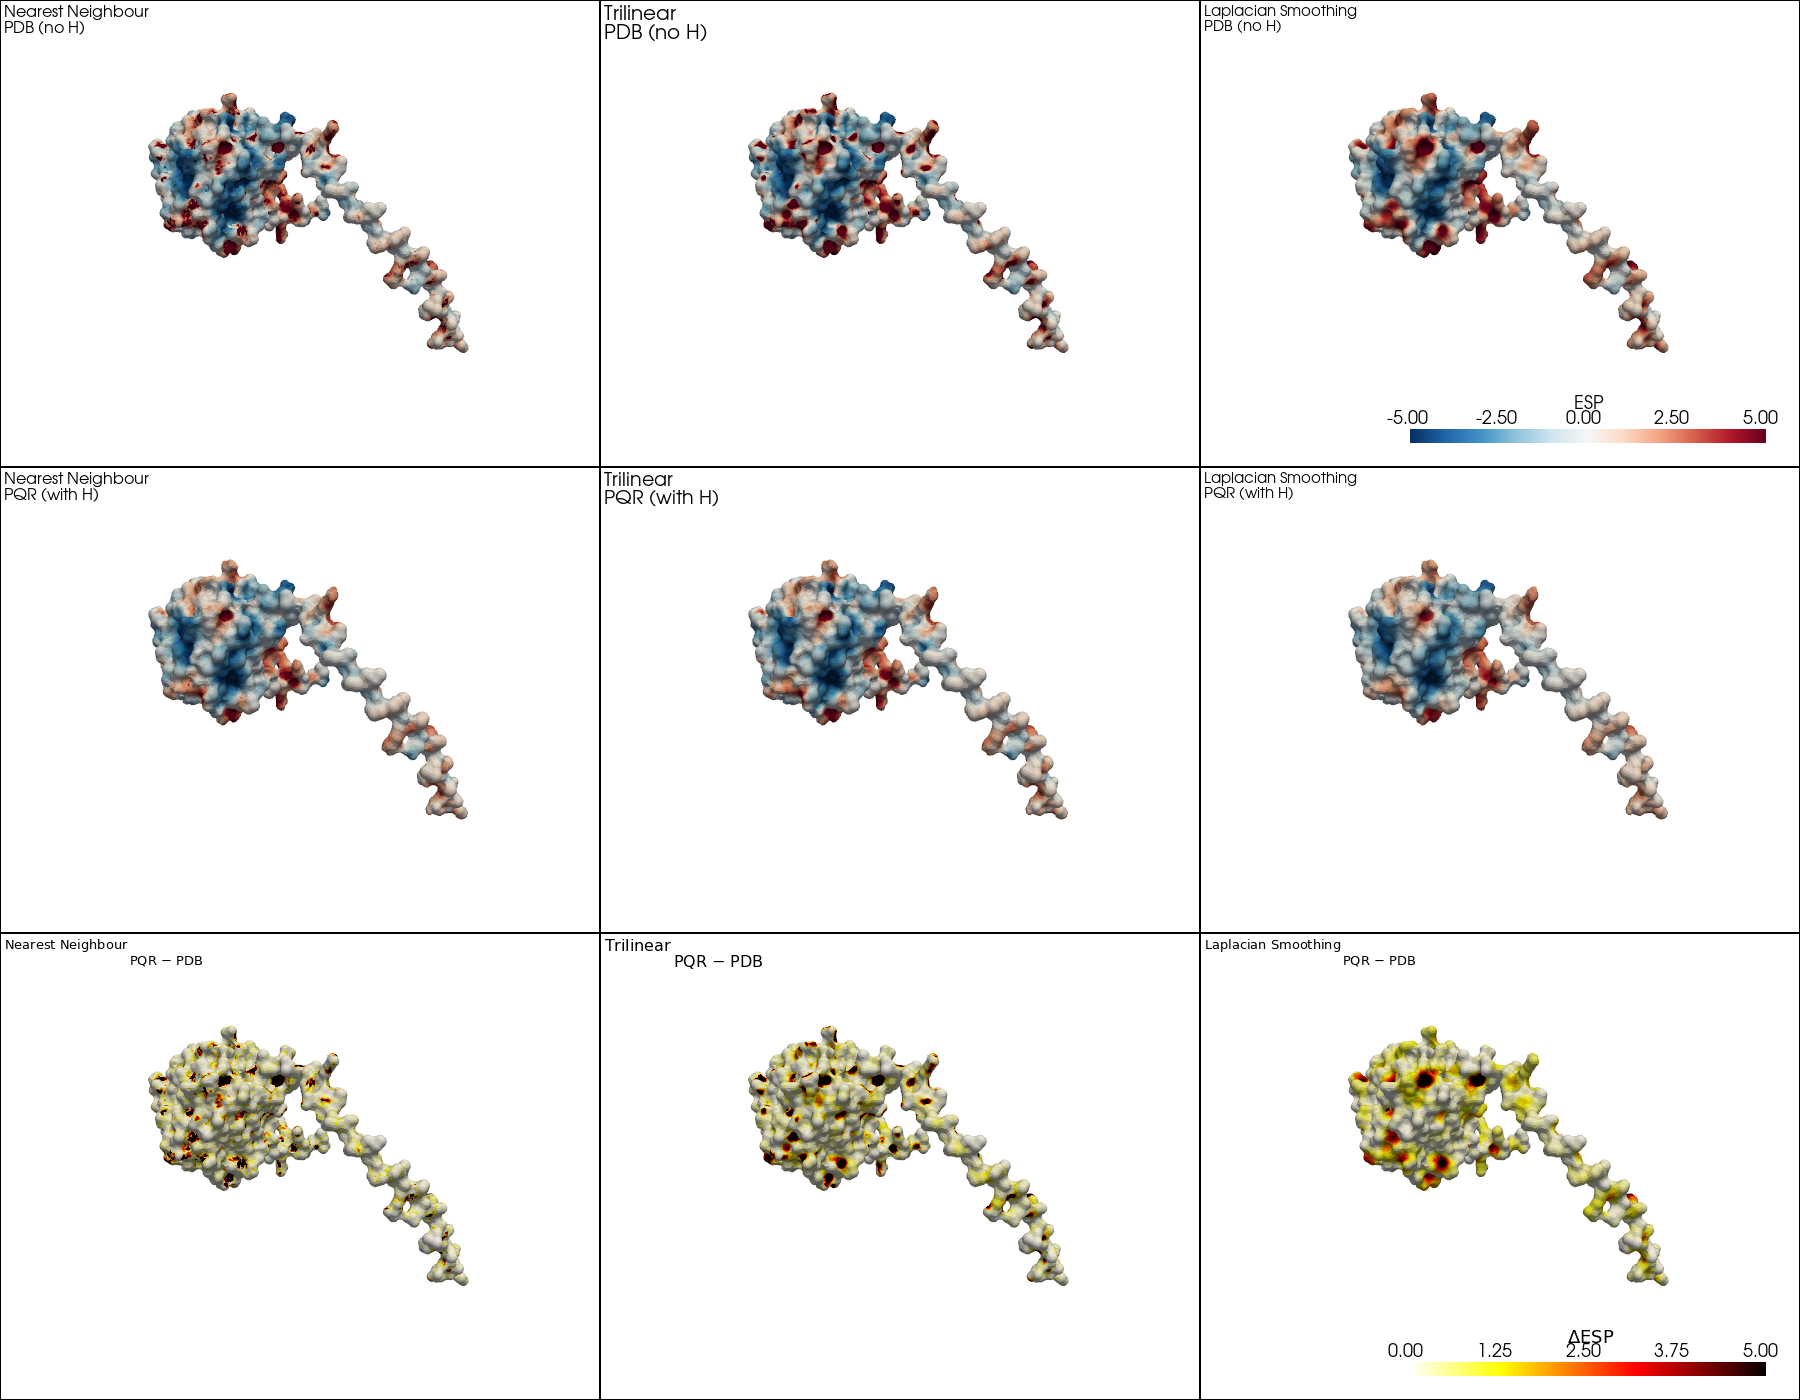

In [27]:
def make_pv_mesh(verts, faces, esp_verts, scalar_name="ESP"):
    n_faces  = len(faces)
    pad      = np.full((n_faces, 1), 3, dtype=int)
    cells    = np.hstack([pad, faces]).ravel()
    surf     = pv.PolyData(verts, cells)
    surf[scalar_name] = esp_verts
    return surf


pid       = PROTEIN_TO_PLOT
verts_pdb = meshes[pid]["pdb"]["verts"]
faces_pdb = meshes[pid]["pdb"]["faces"]
verts_pqr = meshes[pid]["pqr"]["verts"]
faces_pqr = meshes[pid]["pqr"]["faces"]

tree = cKDTree(verts_pqr)
_, idx = tree.query(verts_pdb)

method_labels = ["Nearest Neighbour", "Trilinear", "Laplacian Smoothing"]
method_keys   = ["nearest_neighbour", "trilinear", "laplacian"]

# Camera position — adjust until the view looks right, then run the terminal cell to save
# Common options: "iso", "xy", "xz", "yz"
CAMERA = "iso"

pl = pv.Plotter(shape=(3, 3), window_size=(1800, 1400), off_screen=True)
pl.set_background("white")

for col, (label, key) in enumerate(zip(method_labels, method_keys)):
    esp_pdb = results[pid]["pdb"][key]["esp_verts"]
    esp_pqr = results[pid]["pqr"][key]["esp_verts"]
    diff    = np.abs(esp_pqr[idx] - esp_pdb)

    # Row 0 — PDB
    pl.subplot(0, col)
    pl.add_mesh(make_pv_mesh(verts_pdb, faces_pdb, esp_pdb),
                scalars="ESP", cmap=COLORMAP, clim=CLIM,
                show_scalar_bar=(col == 2))
    pl.add_text(f"{label}\nPDB (no H)", font_size=9)
    pl.camera_position = CAMERA

    # Row 1 — PQR
    pl.subplot(1, col)
    pl.add_mesh(make_pv_mesh(verts_pqr, faces_pqr, esp_pqr),
                scalars="ESP", cmap=COLORMAP, clim=CLIM,
                show_scalar_bar=False)
    pl.add_text(f"{label}\nPQR (with H)", font_size=9)
    pl.camera_position = CAMERA

    # Row 2 — |PQR − PDB|
    pl.subplot(2, col)
    pl.add_mesh(make_pv_mesh(verts_pdb, faces_pdb, diff, scalar_name="|ΔESP|"),
                scalars="|ΔESP|", cmap=DIFF_CMAP, clim=DIFF_CLIM,
                show_scalar_bar=(col == 2))
    pl.add_text(f"{label}\n|PQR − PDB|", font_size=9)
    pl.camera_position = CAMERA

img = pl.screenshot(return_img=True)
pl.close()
buf = io.BytesIO()
PIL.Image.fromarray(img).save(buf, format="PNG")
ipy_display(ipy_Image(data=buf.getvalue(), format="png"))

In [28]:
# ── Interactive window (terminal) ─────────────────────────────────────────────
# Serialises the current results and launches a native window via WSLg.
# Rotate freely, press s to save. Run after the visualisation cell looks right.

import pickle, subprocess, textwrap, tempfile

_data = {
    "results":   results,
    "meshes":    meshes,
    "pid":       PROTEIN_TO_PLOT,
    "METHODS":   method_keys,
    "LABELS":    method_labels,
    "CLIM":      CLIM,
    "DIFF_CLIM": DIFF_CLIM,
    "COLORMAP":  COLORMAP,
    "DIFF_CMAP": DIFF_CMAP,
    "CAMERA":    CAMERA,
}
_pkl = tempfile.NamedTemporaryFile(suffix=".pkl", delete=False)
pickle.dump(_data, open(_pkl.name, "wb"))

_script = textwrap.dedent(f"""
    import pickle, numpy as np, pyvista as pv
    from scipy.spatial import cKDTree

    d = pickle.load(open({repr(_pkl.name)}, "rb"))
    results, meshes, pid = d["results"], d["meshes"], d["pid"]
    METHODS, LABELS = d["METHODS"], d["LABELS"]
    CLIM, DIFF_CLIM = d["CLIM"], d["DIFF_CLIM"]
    COLORMAP, DIFF_CMAP, CAMERA = d["COLORMAP"], d["DIFF_CMAP"], d["CAMERA"]

    def make_pv_mesh(verts, faces, esp, name="ESP"):
        pad   = np.full((len(faces), 1), 3, dtype=int)
        cells = np.hstack([pad, faces]).ravel()
        s = pv.PolyData(verts, cells); s[name] = esp; return s

    verts_pdb, faces_pdb = meshes[pid]["pdb"]["verts"], meshes[pid]["pdb"]["faces"]
    verts_pqr, faces_pqr = meshes[pid]["pqr"]["verts"], meshes[pid]["pqr"]["faces"]
    _, idx = cKDTree(verts_pqr).query(verts_pdb)

    pl = pv.Plotter(shape=(3, 3), window_size=(1800, 1400))
    pl.set_background("white")
    for col, (label, key) in enumerate(zip(LABELS, METHODS)):
        ep   = results[pid]["pdb"][key]["esp_verts"]
        eq   = results[pid]["pqr"][key]["esp_verts"]
        diff = np.abs(eq[idx] - ep)
        for row, (v, f, e, name, clim, cmap) in enumerate([
            (verts_pdb, faces_pdb, ep,   "ESP",    CLIM,      COLORMAP),
            (verts_pqr, faces_pqr, eq,   "ESP",    CLIM,      COLORMAP),
            (verts_pdb, faces_pdb, diff, "|ΔESP|", DIFF_CLIM, DIFF_CMAP),
        ]):
            pl.subplot(row, col)
            pl.add_mesh(make_pv_mesh(v, f, e, name), scalars=name,
                        cmap=cmap, clim=clim,
                        show_scalar_bar=(col == 2 and row != 1))
            pl.add_text(label + ["\\nPDB", "\\nPQR", "\\n|PQR-PDB|"][row], font_size=9)
            pl.camera_position = CAMERA
    pl.link_views()
    pl.show(title=f"{{pid}} — sampling method comparison  [press s to save]")
""")

_sf = tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w")
_sf.write(_script); _sf.close()
subprocess.Popen(["bash", "-c", f"DISPLAY=:0 conda run -n protein_esp python {_sf.name}"])
print("Launched interactive window.")

Launched interactive window.


---
## Notes & Observations

*(Fill in after running — these will inform the THESISPROCESSES.md entry)*

**Nearest Neighbour:**
- 

**Trilinear:**
- 

**Laplacian:**
- 

**H vs no-H difference:**
- 

**Decision:**  
**Rationale:**